In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Bathtub Curve：Changes in asset failure probability with age
# 3 stages：early break-in(low) → 
#               stable operation(slow increase) → 
#                       accelerated aging(repid increase)

age_ratios = np.linspace(0, 1.2, 200)

def bathtub_pof(age_ratio: float) -> float:
    if age_ratio < 0.3:
        return 0.02
    elif age_ratio < 0.7:
        return 0.02 + (age_ratio - 0.3) * 0.1
    else:
        return min(0.06 + (age_ratio - 0.7) * 0.3, 0.95)



Matplotlib is building the font cache; this may take a moment.


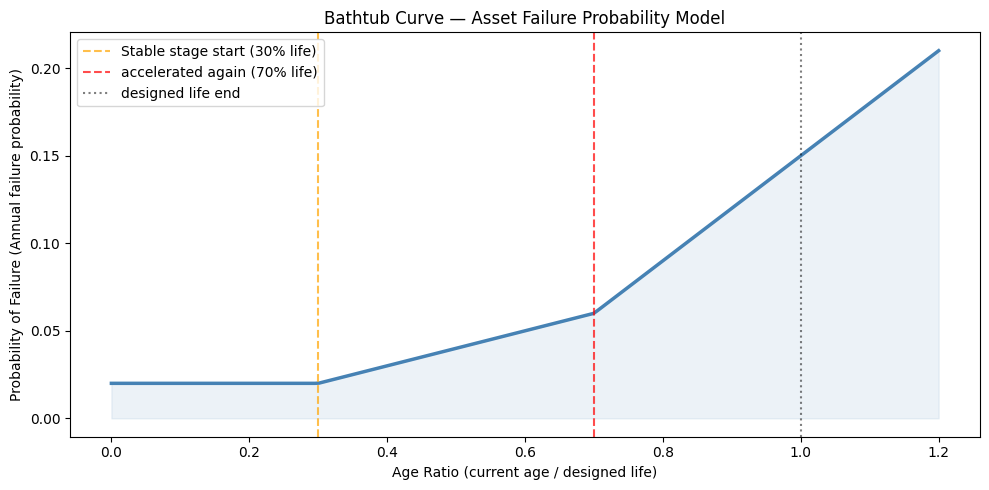

In [2]:
pof_values = [bathtub_pof(r) for r in age_ratios]

plt.figure(figsize=(10, 5))
plt.plot(age_ratios, pof_values, 'steelblue', linewidth=2.5)
plt.axvline(0.3, color='orange', linestyle='--', alpha=0.7, label='Stable stage start (30% life)')
plt.axvline(0.7, color='red',    linestyle='--', alpha=0.7, label='accelerated again (70% life)')
plt.axvline(1.0, color='black',  linestyle=':',  alpha=0.5, label='designed life end')
plt.fill_between(age_ratios, pof_values, alpha=0.1, color='steelblue')
plt.xlabel('Age Ratio (current age / designed life)')
plt.ylabel('Probability of Failure (Annual failure probability)')
plt.title('Bathtub Curve — Asset Failure Probability Model')
plt.legend()
plt.tight_layout()
plt.savefig('../output/bathtub_curve.png', dpi=150)
plt.show()



In [3]:
# An example
print("Transformer (lifespan 35 years):")
for age in [5, 15, 25, 30, 38]:
    ratio = age / 35
    print(f"  {age}年 (ratio={ratio:.2f}): PoF = {bathtub_pof(ratio):.3f}")

Transformer (lifespan 35 years):
  5年 (ratio=0.14): PoF = 0.020
  15年 (ratio=0.43): PoF = 0.033
  25年 (ratio=0.71): PoF = 0.064
  30年 (ratio=0.86): PoF = 0.107
  38年 (ratio=1.09): PoF = 0.176
